In [34]:
import math
import numpy as np
import random
import matplotlib.pyplot as plt

In [35]:
class Value:
    # _children is meant to keep track of the values that underwent an operation to generate this value.
    # _op keeps track of the operation that was done by parent Values to generate this value.
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self): # displays our own data value
        return f"Value(data={self.data})"
    
    def __add__(self, other): # here other is another Value object
        other = other if isinstance(other, Value) else Value(other) # if the passed entity is a Value object then fine, if not then simply wrap it in Value
        out = Value(self.data + other.data, (self, other), '+') # (self, other) = parent Values operating to generate child Value, '+' is the operation done to generate
        def _backward():
            # As mentioned before, '+' operator simply passes the gradient backwards without change.

            # We're writing += instead of + because if a node is being accessed multiple times by different nodes, we want the gradient to not be overridden, but rather accumulated. Hence we add
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) # if the passed entity is a Value object then fine, if not then simply wrap it in Value
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            # As mentioned before, in multiplicative gradient derivation, you take the other node's data, and multiply with the resultant node's grad
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Only int and float support for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * (self.data**(other-1)) * out.grad
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * other**-1
    
    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def exp(self):
        x = self.data 
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)  - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh') # children = (self, ) since this is a single object

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out
    
    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0

        for node in reversed(topo):
            node._backward()
        


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
print(f'Addition: {a + b}')
print(f'Subtraction: {a - b}')
print(f'Multiplication: {a * b}')
print(f'Division: {a / b}')

print(f'Division: {(a / b).data:.1f}') # Fetching data directly and limiting float length

print(f'Can also add a normal number', a + 10)
print(f'Can also multiply a normal number', a * 10)

Addition: Value(data=-1.0)
Subtraction: Value(data=5.0)
Multiplication: Value(data=-6.0)
Division: Value(data=-0.6666666666666666)
Division: -0.7
Can also add a normal number Value(data=12.0)
Can also multiply a normal number Value(data=20.0)


In [36]:
class Neuron:
    def __init__(self, nin): # nin is number of inputs a neuron receives
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x): # called when a notation like n(x) is used.
        # w * x + b | w * x is dot product

        # zip means to take two iterators (w and x) and join them into a new iterator like (w, x).
        # We're taking each paired weight and input and multiplaying them, then summing all the multiplications.
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh() # non-linearity
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout): # nin = dimensionality of neuron in layer, nout = number of neurons in layer
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs # if layer only outputs one value, then output the 0th index otherwise output full list
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters() # parameters of the neuron in the layer
        #     params.extend(ps) # adding all the parameters of all the neurons in the layer
        #     return params

class MLP:
    def __init__(self, nin, nouts): # nin = number of inputs in the MLP, nouts = list of number of neurons in each layer of the MLP
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
        
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

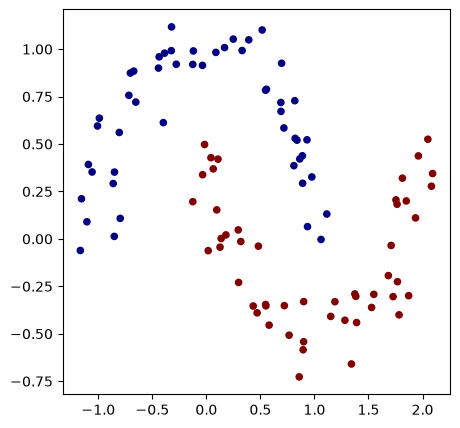

In [37]:
from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [38]:
X.shape, y.shape

((100, 2), (100,))

In [39]:
model = MLP(2, [16, 16, 1]) # 2 features
print(f"Parameters: {len(model.parameters())}")

Parameters: 337


In [40]:
ypred = [model(x) for x in X]
# 10 point outputs
for yp in ypred[:10]:
    print(yp.data)

-0.9542498749667844
-0.9709234714049533
-0.9482755516393363
-0.3672331174313056
-0.9200900887460167
-0.952932516620447
-0.7293032764131041
-0.32542472616411117
0.10884677485304191
-0.9053471450275475


The initial MSE loss value without any training:

In [41]:
loss = sum([(y_output - y_ground_truth)**2 for y_ground_truth, y_output in zip(y, ypred)])
loss

Value(data=159.39267148428814)

In [ ]:
steps = 100

for k in range(steps):
    
    # Forward Pass
    ypred = [model(x) for x in X]

    # Compute Loss
    loss = sum([(y_output - y_ground_truth)**2 for y_ground_truth, y_output in zip(y, ypred)])

    # Zero Grad
    for p in model.parameters():
        p.grad = 0.0

    # Backward Pass
    loss.backward()

    # Update
    for p in model.parameters():
        p.data += -0.04 * p.grad

    print(f"Step {k+1} | Loss: {loss.data}")

Step 1 | Loss: 159.39267148428814
Step 2 | Loss: 172.8076897478388
Step 3 | Loss: 116.16691883499506
Step 4 | Loss: 95.6065163400773
Step 5 | Loss: 85.11546410417706
Step 6 | Loss: 92.57040382191514
Step 7 | Loss: 152.31525617755938
Step 8 | Loss: 91.98971895595113
Step 9 | Loss: 91.98287098400007
Step 10 | Loss: 91.96035455091628
Step 11 | Loss: 91.74556295398637
Step 12 | Loss: 87.91337166646711
Step 13 | Loss: 86.13250333474356
Step 14 | Loss: 86.21701200398113
Step 15 | Loss: 99.95890341175492
Step 16 | Loss: 96.18932581950074
Step 17 | Loss: 74.75611442868558
Step 18 | Loss: 80.74929041358332
Step 19 | Loss: 72.0000000049318
Step 20 | Loss: 72.00000000493179
Step 21 | Loss: 72.00000000493179
Step 22 | Loss: 72.00000000493179
Step 23 | Loss: 72.00000000493179
Step 24 | Loss: 72.00000000493178
Step 25 | Loss: 72.00000000493178
Step 26 | Loss: 72.00000000493178
Step 27 | Loss: 72.00000000493178
Step 28 | Loss: 72.00000000493178
Step 29 | Loss: 72.00000000493178
Step 30 | Loss: 72.000

(-1.6755566468179146, 1.8244433531820854)

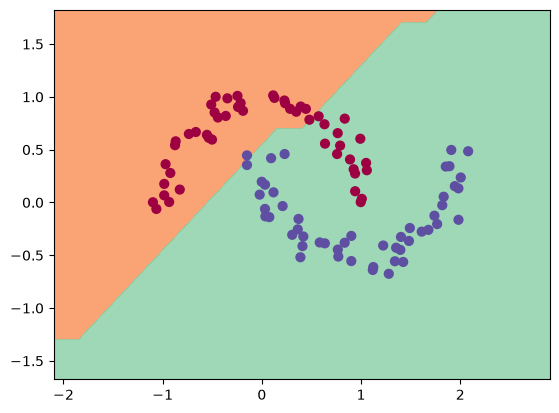

In [ ]:
h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
